In [ ]:
# General libraries for file paths, data extraction, etc
from glob import glob
import os
import urllib3

# Libraries for working with multi-dimensional arrays
import numpy as np
import xarray as xr
import pandas as pd

# Libraries for plotting and visualising data
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Libraries for dealing with time variables
from datetime import datetime

# library for tidal analysis
import hatyan

In [2]:
dir_out_figures = r'p:\1230882-emodnet_hrsm\GTSM-ERA5\validation\gesla\individual_storms'
dir_gtsm = r'p:\archivedprojects\11210221-gtsm-reanalysis\GTSM-ERA5-E_dataset'
dir_gtsm_tide = r'p:\archivedprojects\11205028-c3s_435\01_data\01_Timeseries\timeseries2\tide'

In [ ]:
ds_ges = xr.open_dataset(r'p:\archivedprojects\11210221-gtsm-reanalysis\GESLA\ds_gesla_1950_2022_allstations_50yr_max25prt_missing.nc')

## Select storm

In [54]:
#stormname = "Bhola" 
#stormname = "Gorky"
#stormname = "Sandy"
#stormname = "North Sea Flood"
#stormname = "Camille"
#stormname = "Carla"
#stormname = "Hazel"
stormname = "North Sea Storm"
#stormname = "Hurricane Carla"
#stormname = 'North Sea Flood'
#stormname = 'Typhoon Marie'


In [55]:
if stormname == 'Sandy':
    year = 2012
    timeperiod = ['2012-10-29 00:00', '2012-11-02 00:00']# to check
    loc = [-74.042782, 40.589175]
    locname = "New York, USA"

# elif stormname == "North Sea Flood":
#     year = 1953
#     timeperiod = ['1953-01-31 00:00', '1953-02-01 00:00']# to check
#     loc = [3.679377, 51.637218]
#     locname = "Zeeland, The Netherlands"

# elif stormname == "Bhola":
#     year = 1970
#     timeperiod = ['1970-11-01 00:00', '1970-11-30 23:59']# to check
#     loc = [91.41, 22.72]
#     locname = "Bangladesh"

# elif stormname == "Gorky":
#     year = 1991
#     timeperiod = ['1991-04-01 00:00', '1991-05-31 23:59']# to check
#     loc =[91.810988, 22.214350]
#     locname = "Bangladesh"

# elif stormname == "Sidr":
#     year = 2007
#     timeperiod = ['2007-11-01 00:00', '2007-11-30 23:59']# to check
#     loc =[89.901844, 21.943066]
#     locname = "Bangladesh"

# elif stormname == "Hazel":
#     year = 1954
#     timeperiod = ['1954-10-01 00:00', '1954-10-31 23:59']# to check
#     loc =[-78.496580, 33.865968]
#     locname = "Calabash, North Carolina, USA"

# elif stormname == "Camille":
#     year = 1969
#     timeperiod = ['1969-08-01 00:00', '1969-08-31 23:59']# to check
#     loc =[-89.245709, 30.310021]
#     locname = "New Orleans, USA"
    
elif stormname == "Carla":
    year = 1961
    timeperiod = ['1961-09-09 12:00', '1961-09-13 12:00'] 
    loc =[-94.79, 29.31] 
    locname = "Galveston, USA"
    geslaname = "Galveston_Pier_21"

elif stormname == "North Sea Storm":
    year = 1968
    timeperiod = ['1968-01-13 12:00', '1968-01-17 12:00']
    loc =[8.43, 55.47]
    locname = "Esbjerg, Denmark"
    geslaname = "Esbjerg"

# elif stormname == 'North Sea Flood':
#     year = 1962
#     month = [2]
#     loc =[8.72, 53.87]
#     locname = "Cuxhaven, Germany"
#     geslaname = "Cuxhaven"

elif stormname == 'Typhoon Marie':
    year = 1954
    timeperiod = ['1954-09-11 12:00', '1954-09-15 12:00']
    loc =[131.67, 32.43]
    locname = "Hosojima, Japan"
    geslaname = "Hosojima"



## Retrieve GTSM data

In [56]:
files_gtsm = glob(os.path.join(dir_gtsm, 'waterlevel', f"reanalysis_waterlevel_hourly_{year}_*_v3.nc"))

ds_wl = xr.open_mfdataset(files_gtsm)
ds_wl = ds_wl.chunk({'time': 720, 'stations': 2000})
ds_wl

files_gtsm_sur = [x.replace('waterlevel','surge') for x in files_gtsm]
ds_sur = xr.open_mfdataset(files_gtsm_sur)
ds_sur = ds_sur.chunk({'time': 720, 'stations': 2000}) 

In [57]:
files_gtsm_tide = glob(os.path.join(dir_gtsm_tide, f"*_{year}_*.nc"))

ds_tide = xr.open_mfdataset(files_gtsm_tide)
ds_tide = ds_tide.chunk({'time': 720*6, 'stations': 2000}) 
ds_tide

<xarray.Dataset> Size: 18GB
Dimensions:               (time: 52704, stations: 43119)
Coordinates:
  * time                  (time) datetime64[ns] 422kB 1968-01-01 ... 1968-12-...
  * stations              (stations) uint16 86kB 0 1 2 3 ... 43731 43732 43733
    station_x_coordinate  (stations) float64 345kB dask.array<chunksize=(2000,), meta=np.ndarray>
    station_y_coordinate  (stations) float64 345kB dask.array<chunksize=(2000,), meta=np.ndarray>
Data variables:
    tide                  (time, stations) float64 18GB dask.array<chunksize=(4320, 2000), meta=np.ndarray>
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_tides
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         10-minute timeseries of tide levels
    ...                            ...
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  up
    time_coverage_start:           1968-01-01 00:00:00
    time_coverage_end:             1968-01-31 23:50:00
    experiment:                    
    date_modified:                 2021-05-06 10:42:44.816082 UTC

Locate station of interest:

In [58]:
# First, find the index of the grid point nearest a specific lat/lon
abslat = np.abs(ds_wl.station_y_coordinate.values-loc[1])
abslon = np.abs(ds_wl.station_x_coordinate.values-loc[0])
c = np.maximum(abslon, abslat)

([iloc]) = np.where(c == np.min(c))

# get station number in the dataset that corresponds to this location
station = ds_wl.stations.values[iloc[0]]

In [59]:
# subset data to the selected location
ds_wl_loc = ds_wl.sel(stations=station, drop=True)
ds_sur_loc = ds_sur.sel(stations=station, drop=True)
ds_tide_loc = ds_tide.sel(stations=station, drop=True)

In [60]:
ds_sur_loc.load()
ds_wl_loc.load()

<xarray.Dataset> Size: 141kB
Dimensions:     (time: 8784)
Coordinates:
  * time        (time) datetime64[ns] 70kB 1968-01-01 ... 1968-12-31T23:00:00
Data variables:
    waterlevel  (time) float64 70kB 1.036 1.28 1.346 1.139 ... 0.066 0.373 0.674
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_totalwaterlevels
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Hourly timeseries of total water levels
    ...                            ...
    geospatial_vertical_max:       7.788
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  up
    time_coverage_start:           1968-01-01 00:00:00
    time_coverage_end:             1968-01-31 23:00:00
    experiment:                    reanalysis

Define plotting time window:

In [61]:
ds_tide_loc_plot = ds_tide_loc.sel(time=slice(timeperiod[0], timeperiod[1]))
ds_wl_loc_plot = ds_wl_loc.sel(time=slice(timeperiod[0], timeperiod[1]))
ds_sur_loc_plot = ds_sur_loc.sel(time=slice(timeperiod[0], timeperiod[1]))

In [62]:
ds_sur_loc_plot.load()
ds_tide_loc_plot.load()
ds_wl_loc_plot.load()

<xarray.Dataset> Size: 2kB
Dimensions:     (time: 97)
Coordinates:
  * time        (time) datetime64[ns] 776B 1968-01-13T12:00:00 ... 1968-01-17...
Data variables:
    waterlevel  (time) float64 776B 0.923 0.934 0.666 ... -0.084 0.193 0.542
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_totalwaterlevels
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Hourly timeseries of total water levels
    ...                            ...
    geospatial_vertical_max:       7.788
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  up
    time_coverage_start:           1968-01-01 00:00:00
    time_coverage_end:             1968-01-31 23:00:00
    experiment:                    reanalysis

Check tidal timeseries from GTSM derived using linear difference between runs and using harmonic analysis:

(-1.0, 1.0)

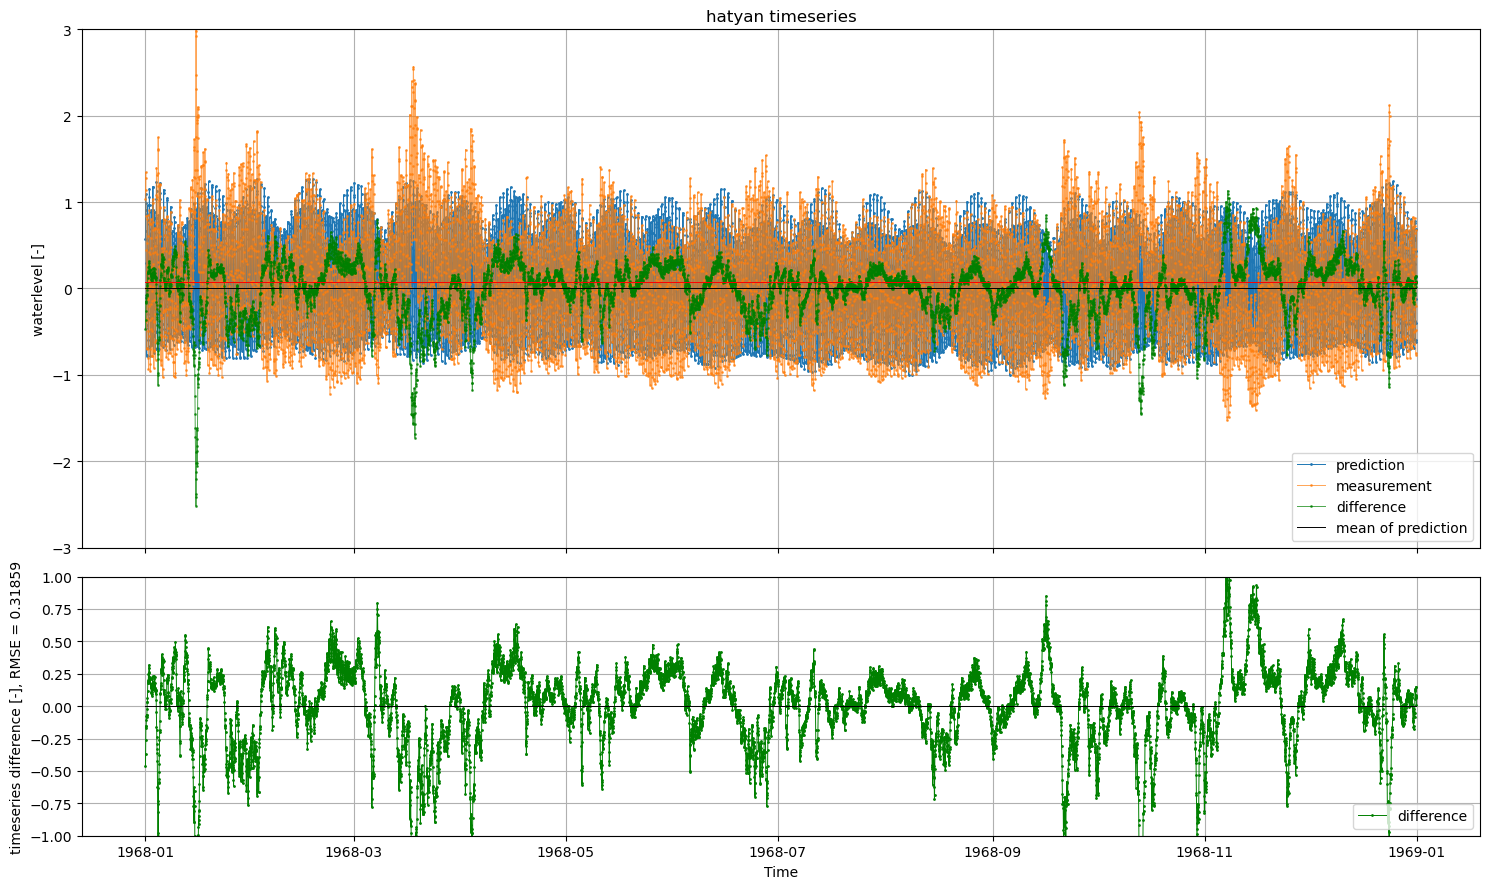

In [63]:
const_list = hatyan.get_const_list_hatyan("year")

ts_gtsm = pd.DataFrame(
                {"values": ds_wl_loc["waterlevel"].values},
                index=pd.to_datetime(ds_wl_loc.time.values),
            )

comp_mean, comp_allperiods = hatyan.analysis(ts=ts_gtsm, const_list=const_list, 
                                               nodalfactors=True, return_allperiods=True,
                                               fu_alltimes=True, analysis_perperiod='Y')

ts_prediction = hatyan.prediction(comp=comp_mean, times=ts_gtsm.index)
fig, (ax1,ax2) = hatyan.plot_timeseries(ts=ts_prediction, ts_validation=ts_gtsm)
ax1.legend(['prediction','measurement','difference','mean of prediction'])
ax2.set_ylim(-1,1)


In [64]:
const_list

['A0',
 'SA',
 'SM',
 'Q1',
 'O1',
 'M1C',
 'P1',
 'S1',
 'K1',
 '3MKS2',
 '3MS2',
 'OQ2',
 'MNS2',
 '2ML2S2',
 'NLK2',
 'MU2',
 'N2',
 'NU2',
 'MSK2',
 'MPS2',
 'M2',
 'MSP2',
 'MKS2',
 'LABDA2',
 '2MN2',
 'T2',
 'S2',
 'K2',
 'MSN2',
 '2SM2',
 'SKM2',
 'NO3',
 '2MK3',
 '2MP3',
 'SO3',
 'MK3',
 'SK3',
 '4MS4',
 '2MNS4',
 '3MS4',
 'MN4',
 '2MLS4',
 '2MSK4',
 'M4',
 '3MN4',
 'MS4',
 'MK4',
 '2MSN4',
 'S4',
 'MNO5',
 '3MK5',
 '2MP5',
 '3MO5',
 'MSK5',
 '3KM5',
 '3MNS6',
 '2NM6',
 '4MS6',
 '2MN6',
 '2MNU6',
 '3MSK6',
 'M6',
 'MSN6',
 'MKNU6',
 '2MS6',
 '2MK6',
 '3MSN6',
 '2SM6',
 'MSK6',
 '2MNO7',
 'M7',
 '2MSO7',
 '2(MN)8',
 '3MN8',
 'M8',
 '2MSN8',
 '2MNK8',
 '3MS8',
 '3MK8',
 '2(MS)8',
 '2MSK8',
 '3MNK9',
 '4MK9',
 '3MSK9',
 '4MN10',
 'M10',
 '3MSN10',
 '4MS10',
 '2(MS)N10',
 '3M2S10',
 '4MSK11',
 'M12',
 '4MSN12',
 '5MS12',
 '4M2S12']

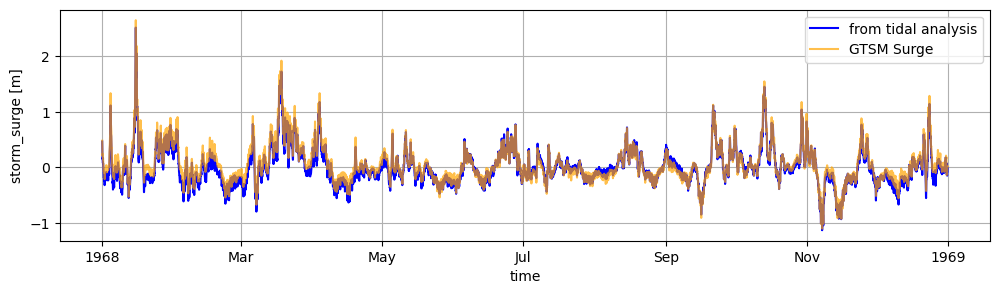

In [65]:
ts_gtsm = ts_gtsm.rename(columns={"values": "sea_level"})

# add ts_prediction to ts_gtsm dataframe
ts_gtsm['tide'] = ts_prediction['values']

# add difference between measured and predicted tide to ts_gtsm dataframe
ts_gtsm['surge'] = ts_gtsm['sea_level'] - ts_gtsm['tide']

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(ts_gtsm.index, ts_gtsm['surge'], color='blue', label='from tidal analysis')
ax.grid()

ds_sur_loc['surge'].plot(ax=ax, color='orange', label='GTSM Surge', alpha=0.7)
#ax.set_xlim([pd.to_datetime(timeperiod[0]), pd.to_datetime(timeperiod[1])])
ax.legend()


## Preprocess observations

In [12]:
ds_ges_sel = ds_ges.where(ds_ges.station_name == geslaname, drop=True)

if len(ds_ges_sel.stations.values) > 1:
    ds_ges_sel = ds_ges_sel.isel(stations=0)

ds_ges_sel['sea_level'] = ds_ges_sel['sea_level'] - ds_ges_sel['sea_level'].sel(time=slice('1986-01-01','2005-12-31')).mean()
ds_ges_sel = ds_ges_sel.squeeze()

In [13]:
ds_ges_sel = ds_ges_sel.sel(time=slice(f'{year}-01-01 00:00', f'{year}-12-31 23:59'))

### Tidal analysis

In [14]:
const_list = hatyan.get_const_list_hatyan("year")
print(const_list)

['A0', 'SA', 'SM', 'Q1', 'O1', 'M1C', 'P1', 'S1', 'K1', '3MKS2', '3MS2', 'OQ2', 'MNS2', '2ML2S2', 'NLK2', 'MU2', 'N2', 'NU2', 'MSK2', 'MPS2', 'M2', 'MSP2', 'MKS2', 'LABDA2', '2MN2', 'T2', 'S2', 'K2', 'MSN2', '2SM2', 'SKM2', 'NO3', '2MK3', '2MP3', 'SO3', 'MK3', 'SK3', '4MS4', '2MNS4', '3MS4', 'MN4', '2MLS4', '2MSK4', 'M4', '3MN4', 'MS4', 'MK4', '2MSN4', 'S4', 'MNO5', '3MK5', '2MP5', '3MO5', 'MSK5', '3KM5', '3MNS6', '2NM6', '4MS6', '2MN6', '2MNU6', '3MSK6', 'M6', 'MSN6', 'MKNU6', '2MS6', '2MK6', '3MSN6', '2SM6', 'MSK6', '2MNO7', 'M7', '2MSO7', '2(MN)8', '3MN8', 'M8', '2MSN8', '2MNK8', '3MS8', '3MK8', '2(MS)8', '2MSK8', '3MNK9', '4MK9', '3MSK9', '4MN10', 'M10', '3MSN10', '4MS10', '2(MS)N10', '3M2S10', '4MSK11', 'M12', '4MSN12', '5MS12', '4M2S12']


In [15]:
ts_ges = pd.DataFrame(
                {"values": ds_ges_sel["sea_level"].values},
                index=pd.to_datetime(ds_ges_sel.time.values),
            )

ts_ges = ts_ges[~ts_ges.index.duplicated()]
ts_ges = ts_ges.dropna()

ts_ges = hatyan.resample_timeseries(
                ts=ts_ges,
                timestep_min=60,
            )
ts_ges.head()

,values
1954-01-01 00:00:00,-0.088423
1954-01-01 01:00:00,-0.118423
1954-01-01 02:00:00,-0.088423
1954-01-01 03:00:00,0.011577
1954-01-01 04:00:00,0.171577


In [16]:
# Use only actually available period,
# not necessarily full Jan-Dec year.
available_start = ts_ges.index.min()
available_end = ts_ges.index.max()
times_ext = [available_start, available_end]

print(f"    Available period: {available_start} to {available_end}")

ts_ges = hatyan.crop_timeseries(
    ts=ts_ges,
    times=slice(times_ext[0], times_ext[1]),
)
ts_ges.head()

    Available period: 1954-01-01 00:00:00 to 1954-12-31 23:00:00


,values
1954-01-01 00:00:00,-0.088423
1954-01-01 01:00:00,-0.118423
1954-01-01 02:00:00,-0.088423
1954-01-01 03:00:00,0.011577
1954-01-01 04:00:00,0.171577


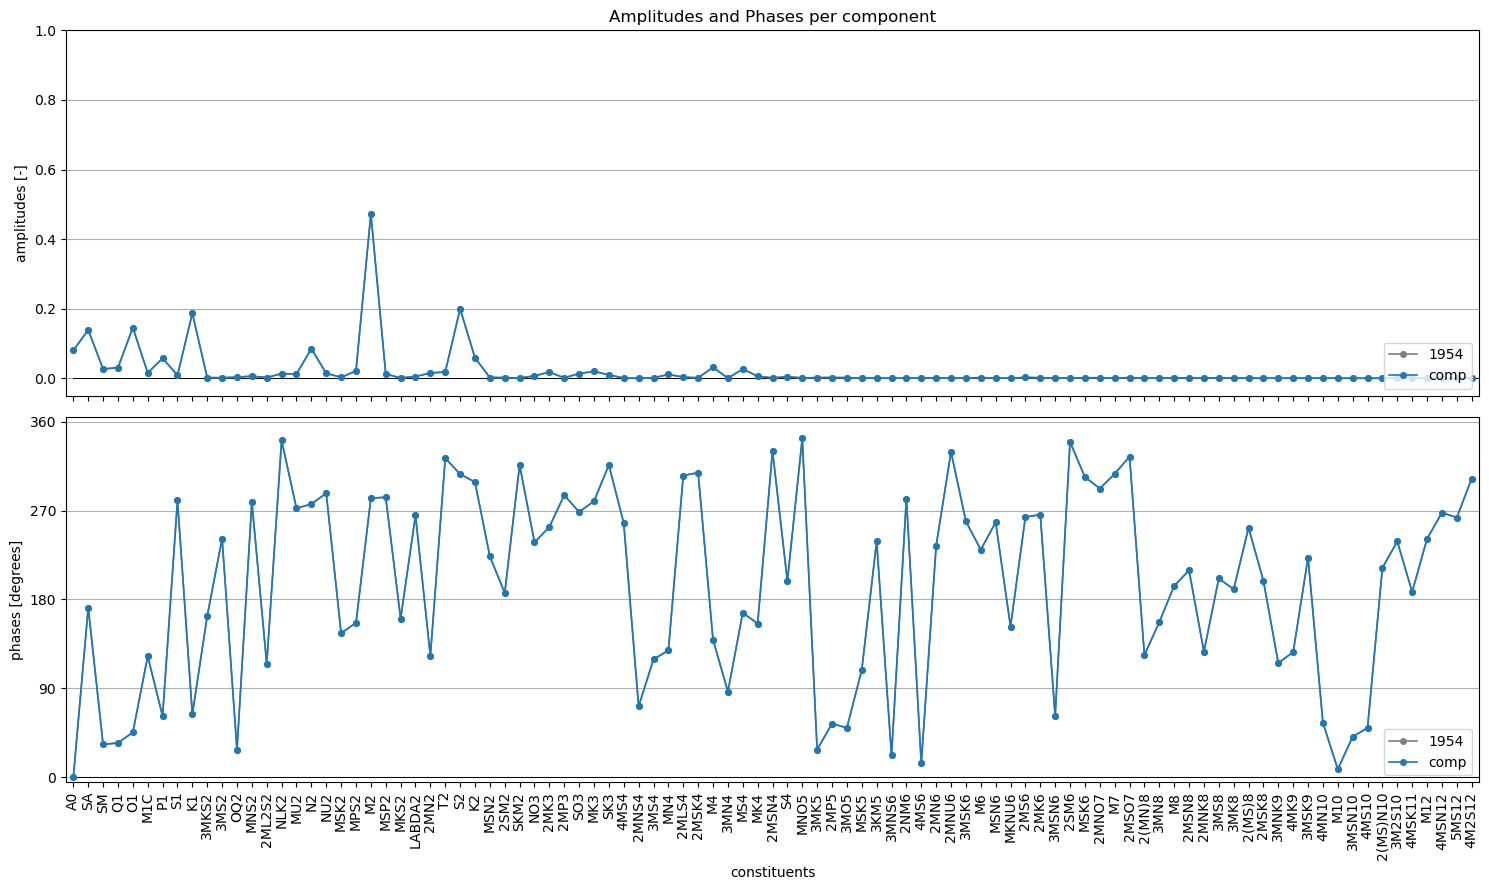

In [17]:
# Tidal harmonic analysis
comp_mean, comp_allperiods = hatyan.analysis(ts=ts_ges, const_list=const_list, 
                                               nodalfactors=True, return_allperiods=True,
                                               fu_alltimes=True, analysis_perperiod='Y')
fig,(ax1,ax2) = hatyan.plot_components(comp=comp_mean, comp_allperiods=comp_allperiods)

In [18]:
# inspect comp_mean 
#print(comp_mean)

               A     phi_deg
A0      0.080010    0.000000
SA      0.139095  171.600085
SM      0.026619   33.111024
Q1      0.030611   34.707528
O1      0.145610   45.411006
...          ...         ...
4MSK11  0.000095  187.602109
M12     0.000134  241.386587
4MSN12  0.000421  267.858849
5MS12   0.000267  262.890145
4M2S12  0.000084  302.415165

[95 rows x 2 columns]


(-1.0, 1.0)

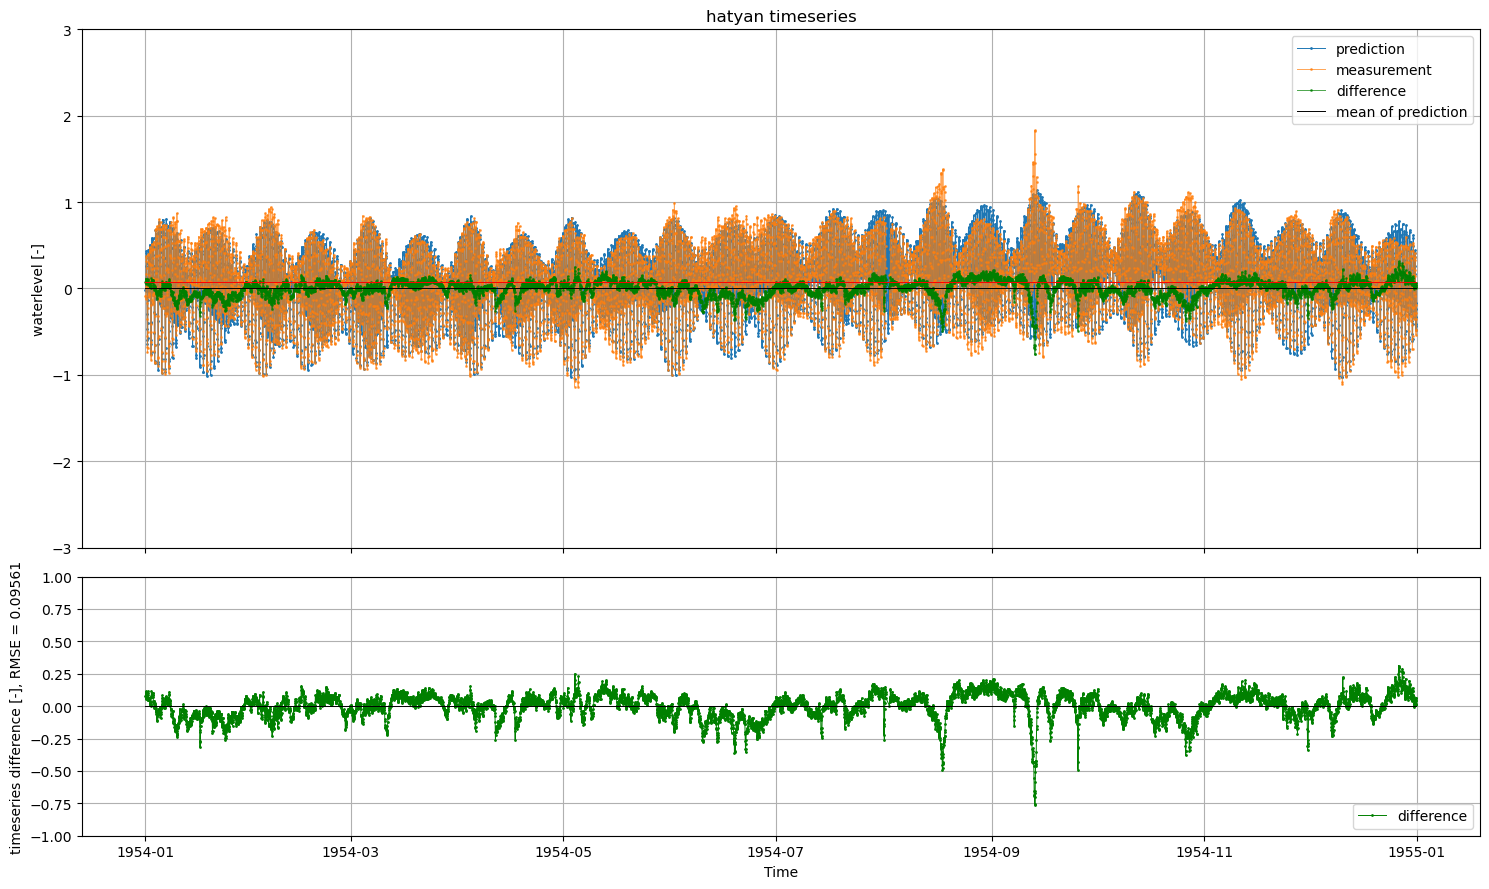

In [19]:
# tidal prediction and plotting of results (prediction settings are derived from the components dataframe)
ts_prediction = hatyan.prediction(comp=comp_mean, times=ts_ges.index)
fig, (ax1,ax2) = hatyan.plot_timeseries(ts=ts_prediction, ts_validation=ts_ges)
ax1.legend(['prediction','measurement','difference','mean of prediction'])
ax2.set_ylim(-1,1)
# fig.savefig('prediction.png')

In [ ]:
ts_ges = ts_ges.rename(columns={"values": "sea_level"})

# add ts_prediction to ts_ges dataframe
ts_ges['tide'] = ts_prediction['values']

# add difference between measured and predicted tide to ts_ges dataframe
ts_ges['surge'] = ts_ges['sea_level'] - ts_ges['tide']


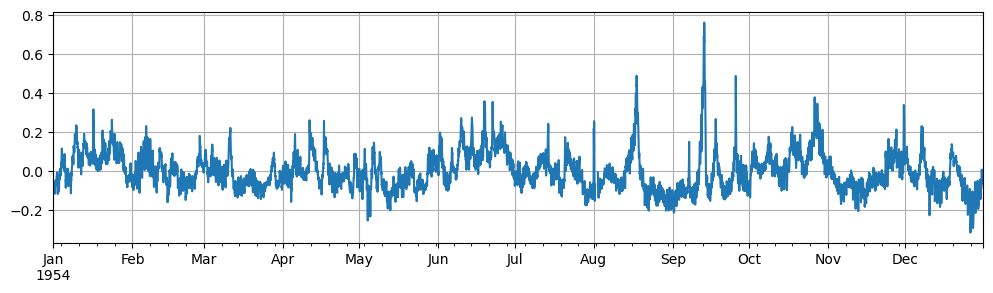

In [21]:
fig,ax = plt.subplots(figsize=(12,3))
ts_ges['surge'].plot(ax=ax)
ax.grid()

## Plot timeseries

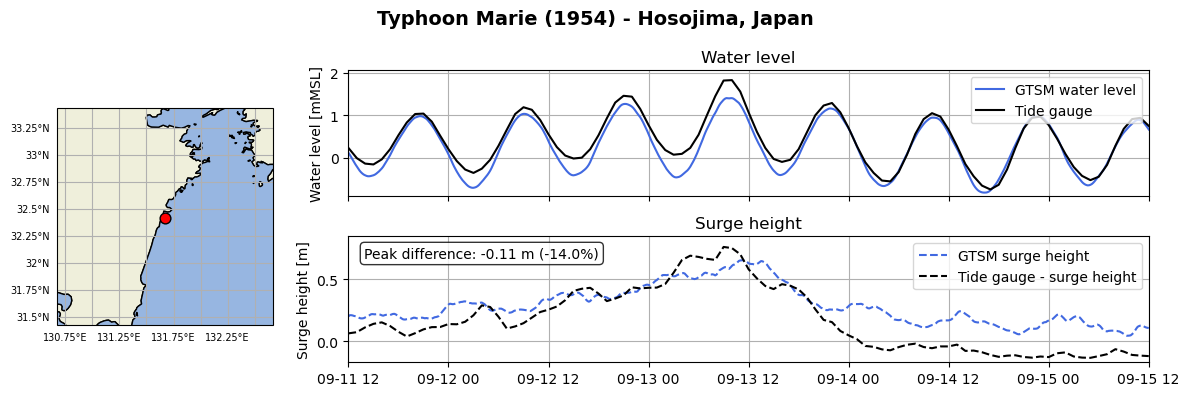

In [22]:
# plot timeseries of water levels and surges at the selected location
from pandas import to_datetime


fig = plt.figure(figsize=(12, 4))
ax0 = plt.subplot2grid((2, 4), (0, 0), rowspan=2, projection=ccrs.PlateCarree())
ax1 = plt.subplot2grid((2, 4), (0, 1), colspan=3, rowspan=1)  # water levels
ax2 = plt.subplot2grid((2, 4), (1, 1), colspan=3, rowspan=1, sharex=ax1)  # surges

#    plot location on the map
ax0.set_xlim([loc[0]-1, loc[0]+1])
ax0.set_ylim([loc[1]-1, loc[1]+1])
ax0.add_feature(cfeature.LAND, edgecolor='black')
ax0.add_feature(cfeature.OCEAN, edgecolor='black')
gl = ax0.gridlines(draw_labels=True)
gl.top_labels = gl.right_labels = False
gl.xlabel_style = {'size': 7}
gl.ylabel_style = {'size': 7}
bs = ax0.scatter(x=ds_wl.sel(stations=station).station_x_coordinate.values,
                 y=ds_wl.sel(stations=station).station_y_coordinate.values,
                 s=60, transform=ccrs.PlateCarree(), facecolors='red', edgecolors='k',
                 linewidth=1, label=f'GTSM output loc. {station}')

# --- Water levels (top right) ---
ax1.plot(ds_wl_loc_plot.time, ds_wl_loc_plot.waterlevel, 'royalblue', label='GTSM water level')
ax1.plot(ts_ges.loc[timeperiod[0]:timeperiod[1]].index, ts_ges['sea_level'].loc[timeperiod[0]:timeperiod[1]], 'k', label='Tide gauge')
ylims1 = ax1.get_ylim()
ax1.set_ylim([ylims1[0]*0.95, ylims1[1]*1.05])
ax1.set_ylabel('Water level [mMSL]', fontsize=10)
ax1.grid()
ax1.legend(loc='upper right')
plt.setp(ax1.get_xticklabels(), visible=False)
ax1.set_title(f"Water level", fontsize=12)

# --- Surge heights (bottom right) ---
ax2.plot(ds_sur_loc_plot.time, ds_sur_loc_plot.surge, 'royalblue', linestyle='--', label='GTSM surge height')
ax2.plot(ts_ges.loc[timeperiod[0]:timeperiod[1]].index, ts_ges['surge'].loc[timeperiod[0]:timeperiod[1]], 'k--', label='Tide gauge - surge height')
ylims2 = ax2.get_ylim()
ax2.set_ylim([ylims2[0]*0.95, ylims2[1]*1.05])
ax2.set_ylabel('Surge height [m]', fontsize=10)
ax2.grid()
ax2.legend(loc='upper right')
ax2.set_xlim([to_datetime(timeperiod[0]), to_datetime(timeperiod[1])])

# --- Surge peak difference text box ---
peak_gtsm = float(ds_sur_loc_plot.surge.max().values)
peak_gesla = float(ts_ges['surge'].loc[timeperiod[0]:timeperiod[1]].max())
diff_abs = peak_gtsm - peak_gesla
diff_pct = diff_abs / peak_gesla * 100
ax2.text(0.02, 0.92,
         f"Peak difference: {diff_abs:+.2f} m ({diff_pct:+.1f}%)",
         transform=ax2.transAxes, va='top', ha='left', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.set_title(f"Surge height", fontsize=12)

fig.suptitle(f'{stormname} ({year}) - {locname}', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(dir_out_figures, f"timeseries_loc_{stormname}_{year}.png"), dpi=300)


## Check spatial distribution of surges

In [429]:
ds_wl_loc.load()
ds_wl_loc_max = ds_wl_loc.where(ds_wl_loc.waterlevel == ds_wl_loc.waterlevel.max(),
                                drop=True).squeeze()

if isinstance(ds_wl_loc_max.time.values.tolist(), list):
    timemax2 = ds_wl_loc_max.time.values[0]
else:
    timemax2 = ds_wl_loc_max.time.values

In [430]:
starttime2 = timemax2 - np.timedelta64(6,'h')
endtime2 = timemax2 + np.timedelta64(6,'h')

In [431]:
# Selecting data for plotting
bbox = [loc[0]-1, loc[1]-1, loc[0]+1, loc[1]+1]
ds_wl.station_x_coordinate.load()
ds_wl.station_y_coordinate.load()
ds_wl_arealoc = ds_wl.where((ds_wl.station_x_coordinate > bbox[0]) &
                           (ds_wl.station_x_coordinate < bbox[2]) &
                           (ds_wl.station_y_coordinate > bbox[1]) &
                           (ds_wl.station_y_coordinate < bbox[3]), drop=True)
ds_wl_arealoc = ds_wl_arealoc.sel(time=slice(starttime2, endtime2))

ds_wl_arealoc.load()  # load data into memory for faster plottingeze()

<xarray.Dataset> Size: 64kB
Dimensions:               (time: 73, stations: 106)
Coordinates:
    station_x_coordinate  (stations) float64 848B 2.703 2.791 ... 3.274 3.113
    station_y_coordinate  (stations) float64 848B 51.16 51.2 ... 51.75 51.38
  * time                  (time) datetime64[ns] 584B 1953-01-31T21:30:00 ... ...
  * stations              (stations) uint16 212B 3895 3896 3897 ... 41018 41019
Data variables:
    waterlevel            (time, stations) float64 62kB -0.057 0.02 ... 0.097
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_totalwaterlevels
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         10-minute timeseries of total water levels
    ...                            ...
    geospatial_vertical_max:       8.038
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  up
    time_coverage_start:           1953-01-01 00:00:00
    time_coverage_end:             1953-01-31 23:50:00
    experiment:                    reanalysis

In [432]:
wl_max = ds_wl_arealoc.waterlevel.max().values.tolist()
wl_max

4.49

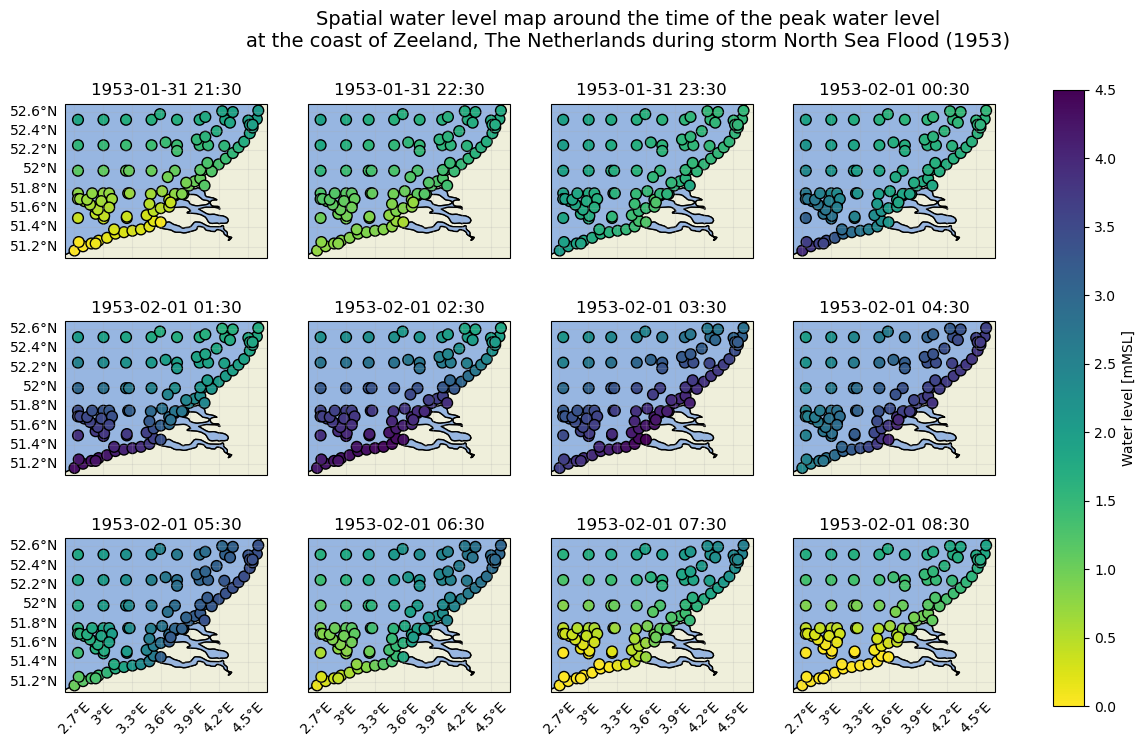

In [433]:
# Plotting the data

# Colorbar limits for total water levels based on the maximum value at the location of interest
lims = [0, np.round(wl_max,1)]

# Initiate the plot with four subplots
fig, axs = plt.subplots(nrows=3, ncols=4,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(15, 8))
axs = axs.flatten()

# Loop over timesteps and plot each in a separate axis
for ii, timestamp in enumerate(ds_wl_arealoc.time.values[:72:6]):
    im = axs[ii].scatter(x=ds_wl_arealoc.station_x_coordinate, y=ds_wl_arealoc.station_y_coordinate,
                         s=60, c=ds_wl_arealoc['waterlevel'].sel(time=timestamp),
                         cmap='viridis_r', edgecolor='k', vmin=lims[0], vmax=lims[1])

    # Add land feature
    axs[ii].add_feature(cfeature.LAND, edgecolor='black')
    axs[ii].add_feature(cfeature.OCEAN, edgecolor='black')

    # add gridlines
    gl = axs[ii].gridlines(draw_labels=False, color='darkgrey', alpha=0.2)
    gl.left_labels = True if ii % 4 == 0 else False
    
    if int(ii / 4) == 2:
        gl.bottom_labels = True 
        gl.xlabel_style = {'rotation': 45}
    else: 
        gl.bottom_labels = False

    # add timestamp as title
    axs[ii].set_title(np.datetime_as_string(timestamp, unit='m').replace('T', ' '))

fig.colorbar(im, ax=axs.ravel().tolist(), label='Water level [mMSL]')

# Add title
fig.suptitle("Spatial water level map around the time of the peak water level\n" +
             f"at the coast of {locname} during storm {stormname} ({year})", fontsize=14)
# Save the figure
fig.savefig(os.path.join(root, f"spatial_waterlevels_{stormname}.png"), dpi=300)